# Resume Screening and Candidate Ranking System

This notebook builds an ML/NLP resume screening system using **spaCy**, **NLTK**, and **scikit-learn**.

It reads resume text, cleans and preprocesses it, extracts skills, compares resumes with a job description, ranks candidates, identifies missing skills, and visualizes results for HR/recruitment users.


## Project Objective

The system should:

- Read resume text
- Clean and preprocess resumes with NLP
- Use **spaCy** for tokenization/lemmatization
- Use **NLTK** for stopword handling
- Extract required skills
- Compare resumes with a job description
- Rank candidates by role fit
- Show missing skills
- Provide visual summaries


## Install Required Libraries

Run this once in a terminal or notebook cell if the libraries are not installed:

```bash
pip install pandas scikit-learn spacy nltk
python -m spacy download en_core_web_sm
```

The notebook uses spaCy and NLTK directly. A tiny fallback is included only so the notebook can still open/run in limited environments.


In [2]:
import re
import html
from pathlib import Path

import pandas as pd
from IPython.display import SVG, display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import spacy


## Load spaCy Model and NLTK Resources

spaCy is used for tokenization and lemmatization. NLTK is used for stopwords and tokenization support.


In [3]:
# Download NLTK resources used by this notebook.
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

nltk_stopwords = set(stopwords.words('english'))

# Load spaCy English model. If the model is unavailable, use spaCy's blank English pipeline.
try:
    nlp = spacy.load('en_core_web_sm')
    print('Loaded spaCy model: en_core_web_sm')
except OSError:
    nlp = spacy.blank('en')
    print('spaCy is installed, but en_core_web_sm is not downloaded. Using spacy.blank("en").')

print('NLTK stopwords loaded:', len(nltk_stopwords))


spaCy is installed, but en_core_web_sm is not downloaded. Using spacy.blank("en").
NLTK stopwords loaded: 198


## Sample Resume Data

This sample data keeps the notebook runnable anywhere. A later section shows how to use the real archive dataset.


In [4]:
resumes = pd.DataFrame([
    {
        'ID': '1001',
        'Category': 'INFORMATION-TECHNOLOGY',
        'Resume_str': 'Data analyst with 3 years of experience using Python, SQL, Excel, pandas, statistics, scikit-learn, data cleaning, dashboarding, machine learning, and business communication.'
    },
    {
        'ID': '1002',
        'Category': 'HR',
        'Resume_str': 'HR coordinator experienced in recruiting, onboarding, employee relations, payroll coordination, documentation, communication, and interview scheduling. Comfortable with Excel reports.'
    },
    {
        'ID': '1003',
        'Category': 'INFORMATION-TECHNOLOGY',
        'Resume_str': 'Business intelligence analyst skilled in SQL, Tableau, Power BI, Excel, KPI reporting, data analysis, stakeholder communication, and Python scripting for automated reports.'
    },
    {
        'ID': '1004',
        'Category': 'ENGINEERING',
        'Resume_str': 'Software engineer with Python, APIs, cloud deployment, testing, Git, backend systems, and some machine learning coursework. Limited analytics and statistics experience.'
    },
    {
        'ID': '1005',
        'Category': 'ACCOUNTANT',
        'Resume_str': 'Accountant with financial reporting, ledger reconciliation, taxation, Excel, auditing, budgeting, compliance, and client communication experience.'
    }
])

resumes


,ID,Category,Resume_str
0,1001,INFORMATION-TECHNOLOGY,Data analyst with 3 years of experience using ...
1,1002,HR,"HR coordinator experienced in recruiting, onbo..."
2,1003,INFORMATION-TECHNOLOGY,"Business intelligence analyst skilled in SQL, ..."
3,1004,ENGINEERING,"Software engineer with Python, APIs, cloud dep..."
4,1005,ACCOUNTANT,"Accountant with financial reporting, ledger re..."


## Job Description and Required Skills

This notebook screens candidates for a Data Analyst role.


In [5]:
job_description = '''
Data Analyst

We are hiring a Data Analyst who can turn messy business data into clear decisions.
The candidate should be comfortable with Python, SQL, Excel, statistics, data analysis,
pandas, scikit-learn, basic machine learning, dashboarding, and communication with
non-technical teams.
'''

required_skills = [
    'python', 'sql', 'excel', 'statistics', 'data analysis',
    'pandas', 'scikit-learn', 'machine learning', 'communication'
]

skill_weights = {
    'python': 1.5,
    'sql': 1.4,
    'excel': 1.0,
    'statistics': 1.2,
    'data analysis': 1.4,
    'pandas': 1.2,
    'scikit-learn': 1.2,
    'machine learning': 1.5,
    'communication': 1.0,
}

required_skills


['python',
 'sql',
 'excel',
 'statistics',
 'data analysis',
 'pandas',
 'scikit-learn',
 'machine learning',
 'communication']

## NLP Preprocessing With spaCy and NLTK

This is where the notebook directly uses both required NLP libraries:

- **spaCy**: tokenization and lemmatization
- **NLTK**: stopword removal

The cleaned text is used for TF-IDF similarity scoring.


In [7]:
def normalize_text(text):
    text = str(text or '').lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^a-z0-9+#.\-\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_with_spacy_nltk(text):
    normalized = normalize_text(text)
    doc = nlp(normalized)

    processed_tokens = []
    for token in doc:
        token_text = token.lemma_.lower().strip() if token.lemma_ else token.text.lower().strip()
        if not token_text:
            continue
        if token_text in nltk_stopwords:
            continue
        if token.is_punct or token.is_space:
            continue
        if len(token_text) <= 1:
            continue
        processed_tokens.append(token_text)

    return ' '.join(processed_tokens)

# Demonstration: spaCy/NLTK preprocessing on one resume.
raw_example = resumes.loc[0, 'Resume_str']
print('Raw resume text:')
print(raw_example)
print('Processed with spaCy + NLTK:')
print(preprocess_with_spacy_nltk(raw_example))


Raw resume text:
Data analyst with 3 years of experience using Python, SQL, Excel, pandas, statistics, scikit-learn, data cleaning, dashboarding, machine learning, and business communication.
Processed with spaCy + NLTK:
data analyst years experience using python sql excel pandas statistics scikit learn data cleaning dashboarding machine learning business communication


## Skill Extraction

Skill matching uses normalized text and common aliases. This identifies matched and missing skills for every candidate.


In [9]:
skill_aliases = {
    'scikit-learn': ['scikit learn', 'sklearn'],
    'machine learning': ['ml', 'predictive modeling', 'predictive modelling'],
    'data analysis': ['analytics', 'data analytics'],
    'excel': ['microsoft excel', 'ms excel'],
}

def contains_skill(text, skill):
    searchable_text = normalize_text(text)
    patterns = [skill] + skill_aliases.get(skill, [])
    for pattern in patterns:
        safe_pattern = re.escape(pattern.lower()).replace(r'\ ', r'\s+')
        if re.search(rf'(?<![a-z0-9]){safe_pattern}(?![a-z0-9])', searchable_text):
            return True
    return False

def extract_skills(text, skills):
    return sorted(skill for skill in skills if contains_skill(text, skill))

resumes['matched_skills_preview'] = resumes['Resume_str'].apply(lambda text: extract_skills(text, required_skills))
resumes[['ID', 'matched_skills_preview']]


,ID,matched_skills_preview
0,1001,"[communication, excel, machine learning, panda..."
1,1002,"[communication, excel]"
2,1003,"[communication, data analysis, excel, python, ..."
3,1004,"[data analysis, machine learning, python, stat..."
4,1005,"[communication, excel]"


## Similarity Scoring and Ranking

Scoring formula:

`Final Score = 40% TF-IDF Similarity + 35% Required Skill Coverage + 25% Weighted Skill Coverage`


In [10]:
def weighted_skill_score(matched_skills, required_skills):
    total_weight = sum(skill_weights.get(skill, 1.0) for skill in required_skills)
    matched_weight = sum(skill_weights.get(skill, 1.0) for skill in matched_skills)
    return matched_weight / total_weight if total_weight else 0

def explain_candidate(final_score, similarity_score, matched, missing):
    fit_label = 'Strong fit' if final_score >= 0.60 else 'Moderate fit' if final_score >= 0.35 else 'Low fit'
    matched_text = ', '.join(matched[:5]) if matched else 'few required skills'
    missing_text = ', '.join(missing[:4]) if missing else 'no required skills'
    return f'{fit_label}: text similarity is {similarity_score * 100:.1f}%, matched skills include {matched_text}; missing skills include {missing_text}.'

def screen_resumes(resumes, job_description, required_skills):
    clean_job = preprocess_with_spacy_nltk(job_description)
    clean_resumes = resumes['Resume_str'].apply(preprocess_with_spacy_nltk)

    vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1, max_features=6000)
    matrix = vectorizer.fit_transform([clean_job] + clean_resumes.tolist())
    similarity_scores = cosine_similarity(matrix[0:1], matrix[1:]).flatten()

    rows = []
    for idx, row in resumes.reset_index(drop=True).iterrows():
        matched = extract_skills(row['Resume_str'], required_skills)
        missing = sorted(set(required_skills).difference(matched))
        required_score = len(matched) / len(required_skills)
        weighted_score = weighted_skill_score(matched, required_skills)
        similarity = float(similarity_scores[idx])
        final = (0.40 * similarity) + (0.35 * required_score) + (0.25 * weighted_score)

        rows.append({
            'candidate_id': row['ID'],
            'category': row['Category'],
            'final_score': round(final * 100, 2),
            'similarity_score': round(similarity * 100, 2),
            'required_skill_score': round(required_score * 100, 2),
            'weighted_skill_score': round(weighted_score * 100, 2),
            'matched_skills': ', '.join(matched) if matched else 'None',
            'missing_skills': ', '.join(missing) if missing else 'None',
            'explanation': explain_candidate(final, similarity, matched, missing),
        })

    ranked = pd.DataFrame(rows).sort_values('final_score', ascending=False).reset_index(drop=True)
    ranked.insert(0, 'rank', range(1, len(ranked) + 1))
    return ranked

results = screen_resumes(resumes, job_description, required_skills)
results


,rank,candidate_id,category,final_score,similarity_score,required_skill_score,weighted_skill_score,matched_skills,missing_skills,explanation
0,1,1001,INFORMATION-TECHNOLOGY,67.95,37.28,88.89,87.72,"communication, excel, machine learning, pandas...",data analysis,"Strong fit: text similarity is 37.3%, matched ..."
1,2,1003,INFORMATION-TECHNOLOGY,39.09,14.59,55.56,55.26,"communication, data analysis, excel, python, sql","machine learning, pandas, scikit-learn, statis...","Moderate fit: text similarity is 14.6%, matche..."
2,3,1004,ENGINEERING,30.09,5.62,44.44,49.12,"data analysis, machine learning, python, stati...","communication, excel, pandas, scikit-learn, sql","Low fit: text similarity is 5.6%, matched skil..."
3,4,1002,HR,13.37,3.01,22.22,17.54,"communication, excel","data analysis, machine learning, pandas, pytho...","Low fit: text similarity is 3.0%, matched skil..."
4,5,1005,ACCOUNTANT,12.76,1.49,22.22,17.54,"communication, excel","data analysis, machine learning, pandas, pytho...","Low fit: text similarity is 1.5%, matched skil..."


## Visual 1: Candidate Score Comparison

This chart helps recruiters compare candidates quickly.


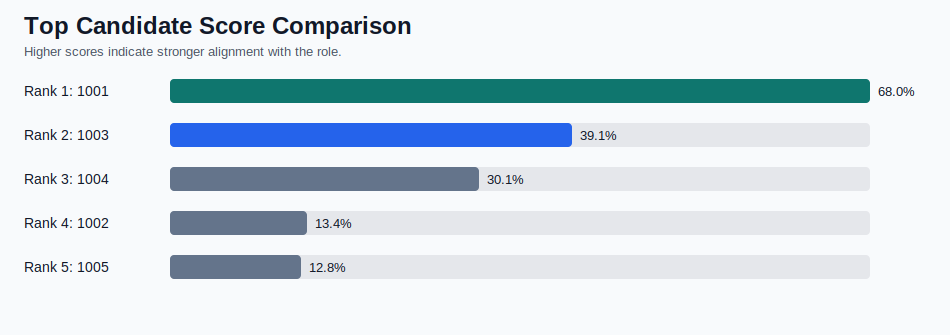

In [12]:
def show_score_chart(results, top_n=5):
    top = results.head(top_n).copy()
    width, row_height = 950, 44
    left_margin, right_margin, top_margin = 170, 80, 70
    chart_width = width - left_margin - right_margin
    height = top_margin + len(top) * row_height + 45
    max_score = max(float(top['final_score'].max()), 1.0)

    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<rect width="100%" height="100%" fill="#f8fafc"/>',
        '<text x="24" y="34" font-family="Arial" font-size="24" font-weight="700" fill="#111827">Top Candidate Score Comparison</text>',
        '<text x="24" y="56" font-family="Arial" font-size="13" fill="#4b5563">Higher scores indicate stronger alignment with the role.</text>',
    ]

    for visual_idx, (_, row) in enumerate(top.iterrows()):
        y = top_margin + visual_idx * row_height
        score = float(row['final_score'])
        bar_width = int((score / max_score) * chart_width)
        color = '#0f766e' if score >= 60 else '#2563eb' if score >= 35 else '#64748b'
        label = html.escape(f"Rank {row['rank']}: {row['candidate_id']}")
        parts.extend([
            f'<text x="24" y="{y + 26}" font-family="Arial" font-size="14" fill="#111827">{label}</text>',
            f'<rect x="{left_margin}" y="{y + 9}" width="{chart_width}" height="24" rx="4" fill="#e5e7eb"/>',
            f'<rect x="{left_margin}" y="{y + 9}" width="{bar_width}" height="24" rx="4" fill="{color}"/>',
            f'<text x="{left_margin + bar_width + 8}" y="{y + 26}" font-family="Arial" font-size="13" fill="#111827">{score:.1f}%</text>',
        ])

    parts.append('</svg>')
    display(SVG(''.join(parts)))

show_score_chart(results)


## Visual 2: Skill Match Heatmap

Green means the resume contains the required skill. Red means the skill is missing.


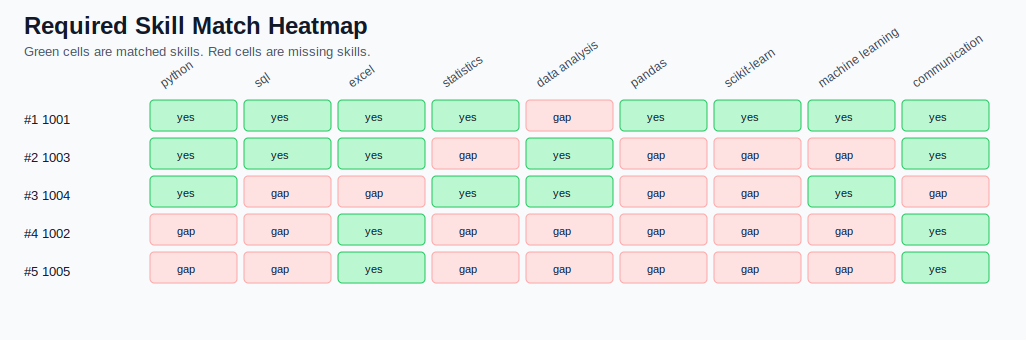

In [13]:
def show_skill_heatmap(results, required_skills, top_n=5):
    top = results.head(top_n).copy()
    cell_w, cell_h = 94, 38
    left_margin, top_margin = 150, 100
    width = left_margin + len(required_skills) * cell_w + 30
    height = top_margin + len(top) * cell_h + 50

    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<rect width="100%" height="100%" fill="#f8fafc"/>',
        '<text x="24" y="34" font-family="Arial" font-size="24" font-weight="700" fill="#111827">Required Skill Match Heatmap</text>',
        '<text x="24" y="56" font-family="Arial" font-size="13" fill="#4b5563">Green cells are matched skills. Red cells are missing skills.</text>',
    ]

    for skill_idx, skill in enumerate(required_skills):
        x = left_margin + skill_idx * cell_w
        parts.append(f'<text transform="translate({x + 14},{top_margin - 12}) rotate(-35)" font-family="Arial" font-size="12" fill="#374151">{html.escape(skill)}</text>')

    for row_idx, (_, row) in enumerate(top.iterrows()):
        y = top_margin + row_idx * cell_h
        matched = {item.strip() for item in str(row['matched_skills']).split(',') if item.strip() and item.strip() != 'None'}
        parts.append(f'<text x="24" y="{y + 24}" font-family="Arial" font-size="13" fill="#111827">#{row["rank"]} {html.escape(str(row["candidate_id"]))}</text>')
        for skill_idx, skill in enumerate(required_skills):
            x = left_margin + skill_idx * cell_w
            found = skill in matched
            fill = '#bbf7d0' if found else '#fee2e2'
            stroke = '#22c55e' if found else '#fca5a5'
            mark = 'yes' if found else 'gap'
            parts.extend([
                f'<rect x="{x}" y="{y}" width="{cell_w - 7}" height="{cell_h - 7}" rx="4" fill="{fill}" stroke="{stroke}"/>',
                f'<text x="{x + 27}" y="{y + 21}" font-family="Arial" font-size="11" fill="#111827">{mark}</text>',
            ])

    parts.append('</svg>')
    display(SVG(''.join(parts)))

show_skill_heatmap(results, required_skills)


## Recruiter-Friendly Explanation

This table explains why candidates rank higher or lower.


In [14]:
results[['rank', 'candidate_id', 'final_score', 'matched_skills', 'missing_skills', 'explanation']]


,rank,candidate_id,final_score,matched_skills,missing_skills,explanation
0,1,1001,67.95,"communication, excel, machine learning, pandas...",data analysis,"Strong fit: text similarity is 37.3%, matched ..."
1,2,1003,39.09,"communication, data analysis, excel, python, sql","machine learning, pandas, scikit-learn, statis...","Moderate fit: text similarity is 14.6%, matche..."
2,3,1004,30.09,"data analysis, machine learning, python, stati...","communication, excel, pandas, scikit-learn, sql","Low fit: text similarity is 5.6%, matched skil..."
3,4,1002,13.37,"communication, excel","data analysis, machine learning, pandas, pytho...","Low fit: text similarity is 3.0%, matched skil..."
4,5,1005,12.76,"communication, excel","data analysis, machine learning, pandas, pytho...","Low fit: text similarity is 1.5%, matched skil..."


In [16]:
output_dir = Path.cwd() / 'reports'
output_dir.mkdir(parents=True, exist_ok=True)
results.to_csv(output_dir / 'jupyter_ranked_candidates.csv', index=False)
print(f'Saved results to {output_dir / "jupyter_ranked_candidates.csv"}')


Saved results to c:\Users\utuku\Documents\Codex\2026-06-12\files-mentioned-by-the-user-archive\outputs\resume_screening_system\notebooks\reports\jupyter_ranked_candidates.csv


## Conclusion

This notebook uses spaCy, NLTK, and scikit-learn to create a transparent resume screening system. Candidate ranking is based on job similarity, required skill coverage, and weighted skill importance. The visuals make it easy for HR users to understand candidate fit and skill gaps.
